In [21]:
from dotenv import load_dotenv
import os
import pandas as pd
from fredapi import Fred

load_dotenv()
api_key = os.getenv("FRED_API_KEY")

fred = Fred(api_key=api_key)

In [22]:
cpi = fred.get_series("CPIAUCSL", observation_start="2020-01-01")
print(cpi.tail(20))

2024-11-01    316.528
2024-12-01    317.604
2025-01-01    318.961
2025-02-01    319.679
2025-03-01    319.785
2025-04-01    320.302
2025-05-01    320.620
2025-06-01    321.435
2025-07-01    322.169
2025-08-01    323.291
2025-09-01    324.245
2025-10-01        NaN
2025-11-01    325.063
2025-12-01    326.031
2026-01-01    326.588
2026-02-01    327.460
2026-03-01    330.293
2026-04-01    332.407
2026-05-01    333.979
2026-06-01    332.568
dtype: float64


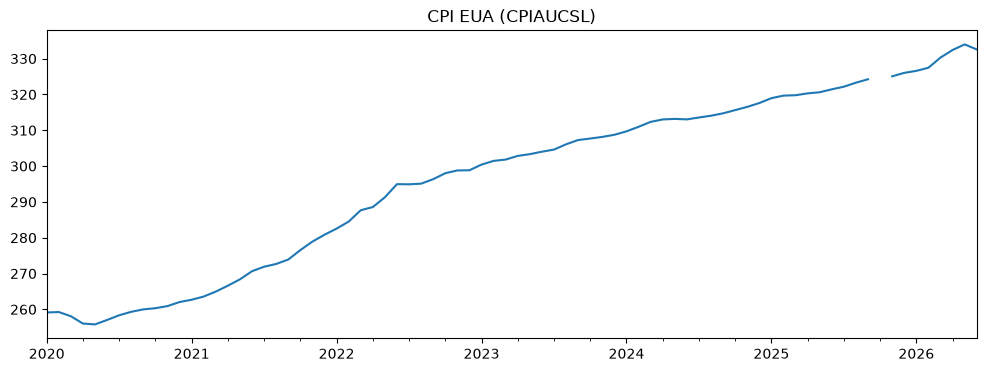

In [23]:
import matplotlib.pyplot as plt

cpi.plot(figsize=(12, 4), title="CPI EUA (CPIAUCSL)")
plt.show()

In [24]:
cpi_recente = cpi["2025-08-01":"2026-08-01"]
print(cpi_recente)

2025-08-01    323.291
2025-09-01    324.245
2025-10-01        NaN
2025-11-01    325.063
2025-12-01    326.031
2026-01-01    326.588
2026-02-01    327.460
2026-03-01    330.293
2026-04-01    332.407
2026-05-01    333.979
2026-06-01    332.568
dtype: float64


No CPI de outubro/2025 foi oficialmente cancelado pelo BLS devido ao shutdown do governo americano (dados de coleta não puderam ser retroativamente recuperados). Esse mês será excluído do conjunto de eventos analisados.

In [25]:
eventos = pd.read_csv("../data/eventos.csv")
print(eventos.columns.tolist())
print(eventos.head())

['indicador', 'data', 'actual', 'forecast', 'diferenca', 'surpresa_zscore']
  indicador        data  actual  forecast  diferenca  surpresa_zscore
0   CPI_EUA  2026-07-14    -0.4      -0.1       -0.3        -3.022518
1   CPI_EUA  2026-06-10     0.5       0.5        0.0         0.000000
2   CPI_EUA  2026-05-12     0.6       0.6        0.0         0.000000
3   CPI_EUA  2026-04-10     0.9       1.0       -0.1        -1.007506
4   CPI_EUA  2026-03-11     0.3       0.3        0.0         0.000000


In [26]:
eventos["diferenca"] = eventos["actual"] - eventos["forecast"]
print(eventos[["indicador", "data", "actual", "forecast", "diferenca"]])

desvio_padrao = eventos["diferenca"].std()
print(f"Desvio-padrão histórico das surpresas de CPI: {desvio_padrao:.4f}")

eventos["surpresa_zscore"] = eventos["diferenca"] / desvio_padrao
print(eventos[["indicador", "data", "actual", "forecast", "diferenca", "surpresa_zscore"]])

   indicador        data  actual  forecast  diferenca
0    CPI_EUA  2026-07-14    -0.4      -0.1       -0.3
1    CPI_EUA  2026-06-10     0.5       0.5        0.0
2    CPI_EUA  2026-05-12     0.6       0.6        0.0
3    CPI_EUA  2026-04-10     0.9       1.0       -0.1
4    CPI_EUA  2026-03-11     0.3       0.3        0.0
5    CPI_EUA  2026-02-13     0.2       0.3       -0.1
6    CPI_EUA  2026-01-13     0.3       0.3        0.0
7    CPI_EUA  2025-10-24     0.3       0.4       -0.1
8    CPI_EUA  2025-09-11     0.4       0.3        0.1
9    CPI_EUA  2025-08-12     0.2       0.2        0.0
10   CPI_EUA  2025-07-15     0.3       0.3        0.0
11   CPI_EUA  2025-06-11     0.1       0.2       -0.1
12   CPI_EUA  2025-05-13     0.2       0.3       -0.1
13   CPI_EUA  2025-04-10    -0.1       0.1       -0.2
14   CPI_EUA  2025-03-12     0.2       0.3       -0.1
15   CPI_EUA  2025-02-12     0.5       0.3        0.2
16   CPI_EUA  2025-01-15     0.4       0.4        0.0
17   CPI_EUA  2024-12-11    

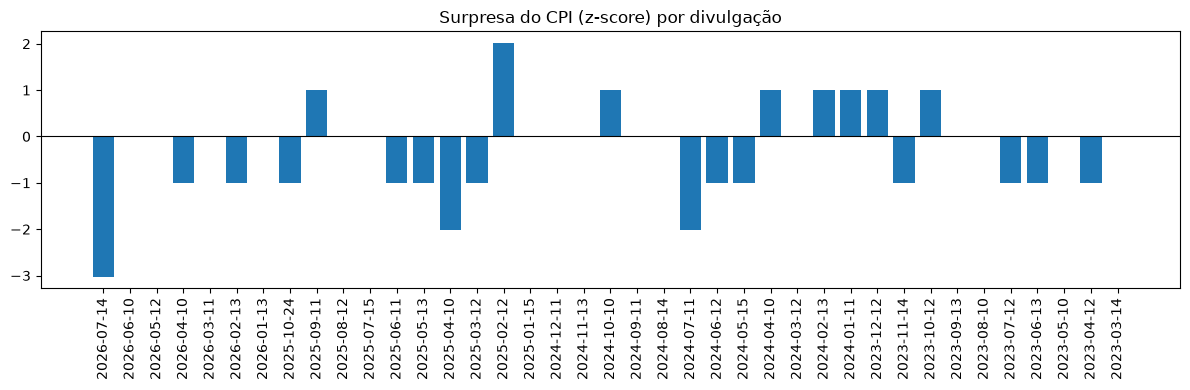

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(eventos["data"], eventos["surpresa_zscore"])
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=90)
plt.title("Surpresa do CPI (z-score) por divulgação")
plt.tight_layout()
plt.show()

In [28]:
eventos.to_csv("C:\Desafio QuantAI\data\eventos.csv", index=False)

In [29]:
import pandas as pd

eventos = pd.read_csv("C:\Desafio QuantAI/data/eventos.csv")
spy = pd.read_csv("C:\Desafio QuantAI/data/spy_precos.csv")

cruzado = eventos.merge(spy, on="data", how="left")
print(cruzado[["data", "surpresa_zscore", "retorno_pct"]])

cruzado.to_csv("C:\Desafio QuantAI/data/eventos_com_retorno.csv", index=False)

          data  surpresa_zscore  retorno_pct
0   2026-07-14        -3.022518     0.355064
1   2026-06-10         0.000000    -1.576556
2   2026-05-12         0.000000    -0.151495
3   2026-04-10        -1.007506    -0.066178
4   2026-03-11         0.000000    -0.125513
5   2026-02-13        -1.007506     0.070450
6   2026-01-13         0.000000    -0.199951
7   2025-10-24        -1.007506     0.817255
8   2025-09-11         1.007506     0.831010
9   2025-08-12         0.000000     1.064598
10  2025-07-15         0.000000    -0.427321
11  2025-06-11        -1.007506    -0.285187
12  2025-05-13        -1.007506     0.660407
13  2025-04-10        -2.015012    -4.381928
14  2025-03-12        -1.007506     0.530660
15  2025-02-12         2.015012    -0.322159
16  2025-01-15         0.000000     1.819003
17  2024-12-11         0.000000     0.773074
18  2024-11-13         0.000000     0.048587
19  2024-10-10         1.007506    -0.175004
20  2024-09-11         0.000000     1.025896
21  2024-0

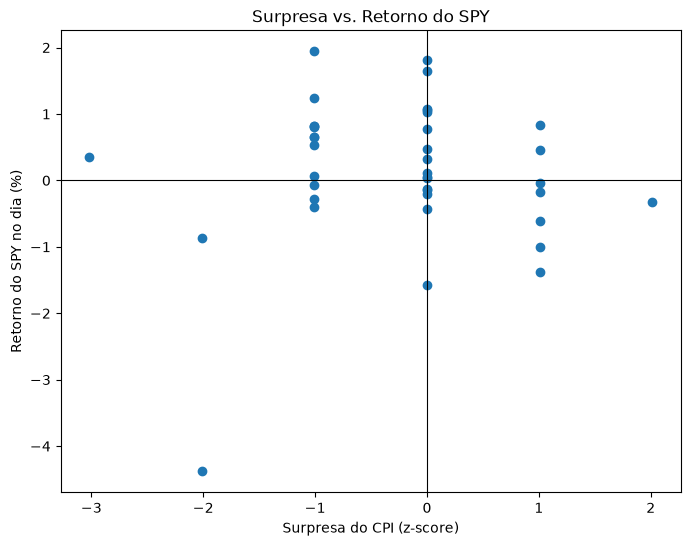

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(cruzado["surpresa_zscore"], cruzado["retorno_pct"])
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Surpresa do CPI (z-score)")
plt.ylabel("Retorno do SPY no dia (%)")
plt.title("Surpresa vs. Retorno do SPY")
plt.show()

plt.savefig("../data/surpresa_vs_retorno.png")